# Blume Catalog Risk Analysis
**Business Analytics Capstone — Operations & Pricing Review**

**Data source:** Live snapshot of Blume's Shopify storefront (meetblume.com), 34 SKUs, captured June 2026.

**Business question:** Assess the health of Blume's product portfolio — identify pricing issues, SKU duplication, and stockout risk concentration — and recommend prioritized actions.

This notebook performs the exploratory analysis and visualization layer of the project. The risk classification (`risk_status`) was generated in SQL Server (see Query 8 in the project's SQL scripts) and is loaded here as the starting point for visualization.

## 1. Setup & Data Loading

The dataset below is the output of **Query 8** (the risk classification query), exported from SQL Server as `products_with_risk.csv`. The CSV was exported without headers, so column names are assigned manually on load, matching Query 8's `SELECT` order.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NOTE: place 'products_with_risk.csv' in the same folder as this notebook
# (or upload it if running in Google Colab)
df = pd.read_csv('products_with_risk.csv', header=None, skiprows=1,
                  names=['title', 'vendor', 'product_type', 'price_min',
                         'on_sale', 'fully_out_of_stock', 'discount_pct', 'risk_status'])
df.head()

,title,vendor,product_type,price_min,on_sale,fully_out_of_stock,discount_pct,risk_status
0,Amazon Prime Day PR Kit,blume-box,Skin Care,175.0,0,0,NaN,Healthy
1,Blume's 8th Birthday PR Kit,blume-box,Skin Care,200.0,0,0,NaN,Healthy
2,Ulta Beauty PR Kit,blume-box,Skin Care,175.0,0,0,NaN,Healthy
3,Blume's 8th Birthday Party: In Full Blume,Blume,Event,55.0,0,1,NaN,Critical - Out of Stock
4,Clear Skin Kit PR Kit,blume-box,Skin Care,85.0,0,0,NaN,Healthy


## 2. Initial Data Overview

Before any analysis, check the shape, types, and completeness of the data. This is a standard first step — it confirms whether numeric columns (`price_min`, `discount_pct`) were read correctly, and shows where `discount_pct` is missing (`NaN`) for products that aren't on sale, which is expected.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               34 non-null     str    
 1   vendor              34 non-null     str    
 2   product_type        34 non-null     str    
 3   price_min           34 non-null     float64
 4   on_sale             34 non-null     int64  
 5   fully_out_of_stock  34 non-null     int64  
 6   discount_pct        16 non-null     float64
 7   risk_status         34 non-null     str    
dtypes: float64(2), int64(2), str(4)
memory usage: 2.3 KB


**Observation:** `discount_pct` has missing values for products where `on_sale = 0` — this is expected, since a product not on sale has no discount to report. These rows are correctly excluded from any discount-based averages later in this notebook.

In [3]:
df['risk_status'].value_counts()

risk_status
Healthy                      16
Watch - On Sale               7
High Risk - Deep Discount     6
Critical - Out of Stock       5
Name: count, dtype: int64

**Finding:** Of 34 SKUs, **18 (53%)** fall into an "at-risk" category — 7 Watch, 6 High Risk - Deep Discount, and 5 Critical - Out of Stock. Only 16 (47%) are classified as Healthy. This single number is the headline statistic for the project's executive summary.

## 3. Chart 1 — Risk Distribution

This chart visualizes the 53%-at-risk finding above, ordered by severity (most severe first) so the chart reads left-to-right as "worst to best" rather than by raw frequency.

/tmp/ipykernel_598/2361106291.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_counts.index, y=risk_counts.values, palette=colors)


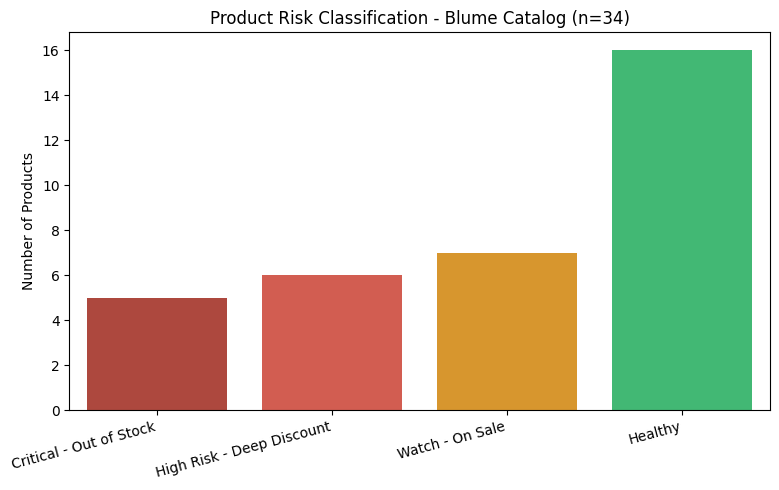

In [4]:
risk_order = ['Critical - Out of Stock', 'High Risk - Deep Discount', 'Watch - On Sale', 'Healthy']
risk_counts = df['risk_status'].value_counts().reindex(risk_order)

plt.figure(figsize=(8,5))
colors = ['#c0392b', '#e74c3c', '#f39c12', '#2ecc71']
sns.barplot(x=risk_counts.index, y=risk_counts.values, palette=colors)
plt.title('Product Risk Classification - Blume Catalog (n=34)')
plt.ylabel('Number of Products')
plt.xlabel('')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('risk_distribution.png', dpi=150)
plt.show()

## 4. Chart 2 — Discount % Distribution by Product Type

This boxplot shows the spread of discount percentages within each product category, with individual products overlaid as points (since the dataset is small, a plain boxplot alone would look sparse). The goal is to spot whether deep discounts are concentrated in one category or spread evenly.

/tmp/ipykernel_598/3975519905.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='product_type', y='discount_pct', palette='Set2')


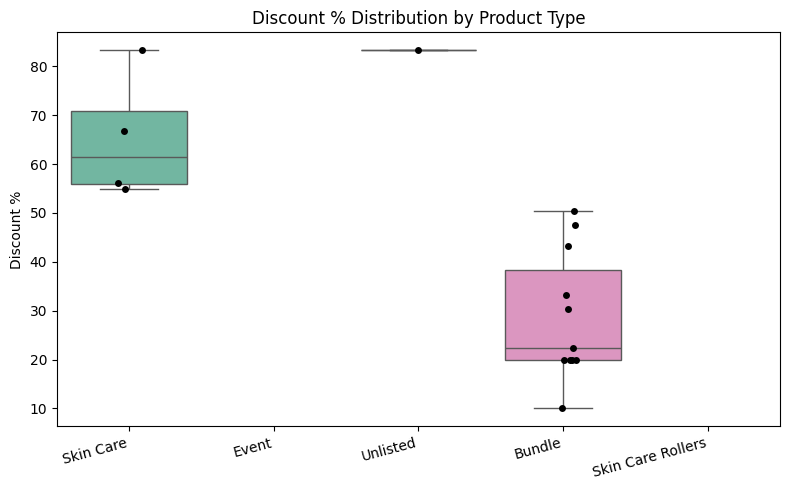

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='product_type', y='discount_pct', palette='Set2')
sns.stripplot(data=df, x='product_type', y='discount_pct', color='black', size=5, jitter=True)
plt.title('Discount % Distribution by Product Type')
plt.ylabel('Discount %')
plt.xlabel('')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('discount_by_category.png', dpi=150)
plt.show()

**Finding:** Two products — *Meltdown Acne Oil Treatment* (Unlisted) and *Meltdown Gel Cream with Ceramides* (Skin Care) — both sit at an **83.3% discount**, well above their category peers. Skin Care shows the widest spread of discounts (10% to 83.3%), while Bundle discounts cluster more tightly around 20-50%, suggesting two different discounting strategies are in play across the catalog.

## 5. Chart 3 — On-Sale Rate by Vendor Line

Blume's catalog is split across two vendor groupings: `Blume` (primarily bundles/kits) and `blume-box` (primarily standalone skincare). This chart compares how aggressively each line is discounted.

/tmp/ipykernel_598/2689609287.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vendor_stats, x='vendor', y='on_sale_pct', palette='Set1', ax=ax)


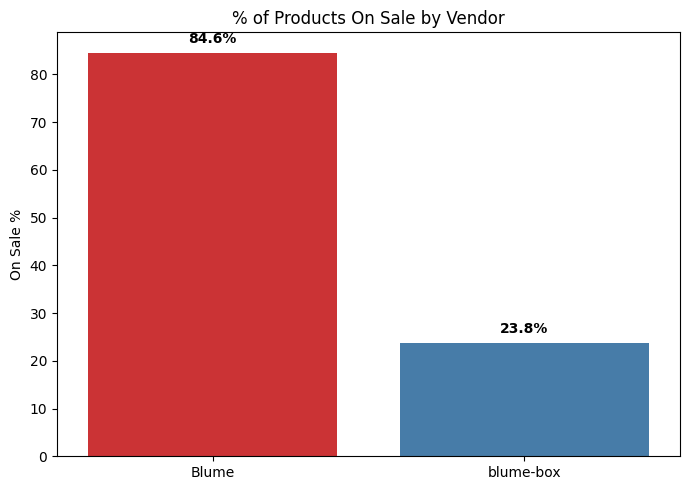

,vendor,total_products,on_sale_pct,oos_count
0,Blume,13,84.6,4
1,blume-box,21,23.8,1


In [6]:
vendor_stats = df.groupby('vendor').agg(
    total_products=('title', 'count'),
    on_sale_pct=('on_sale', lambda x: round(100*x.sum()/len(x), 1)),
    oos_count=('fully_out_of_stock', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(data=vendor_stats, x='vendor', y='on_sale_pct', palette='Set1', ax=ax)
ax.set_title('% of Products On Sale by Vendor')
ax.set_ylabel('On Sale %')
ax.set_xlabel('')
for i, row in vendor_stats.iterrows():
    ax.text(i, row['on_sale_pct']+2, f"{row['on_sale_pct']}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('vendor_on_sale.png', dpi=150)
plt.show()

vendor_stats

**Finding — the strongest signal in this dataset:** the `Blume` line (bundles) has **84.6%** of its products on sale, versus **23.8%** for `blume-box` (standalone items) — a near 4x difference. The `Blume` line also accounts for **4 of the 5** fully out-of-stock products, despite having fewer total SKUs (13 vs 21). The bundle line is simultaneously the most heavily discounted *and* the most stock-constrained part of the catalog — a tension worth flagging to operations and merchandising.

## 6. Chart 4 — Price vs. Discount, by Risk Status

Rather than a clustering model (which isn't well-suited to a 34-row, mostly-categorical dataset), this scatter plot directly visualizes the relationship between a product's price and its discount level, colored by risk tier. This makes the two 83.3%-discount outliers immediately visible and shows whether higher-priced items are discounted more or less aggressively than lower-priced ones.

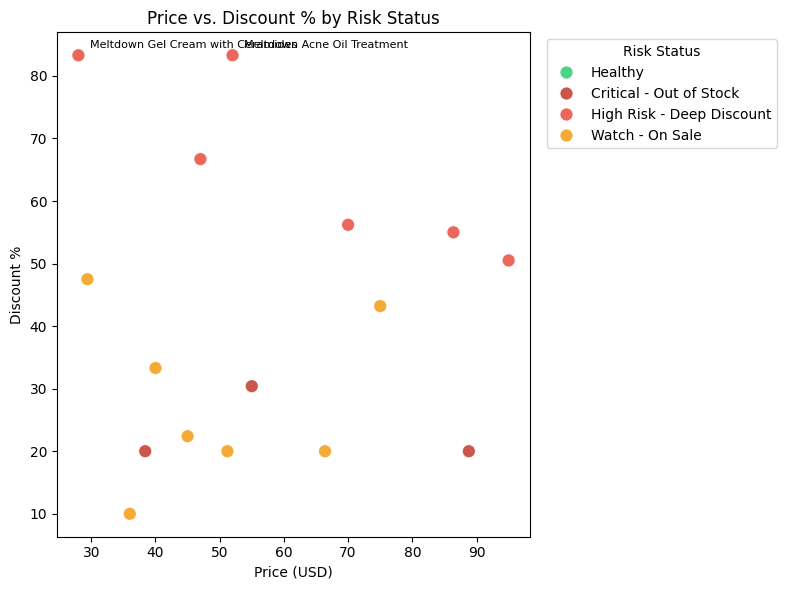

In [7]:
plt.figure(figsize=(8,6))
palette = {
    'Healthy': '#2ecc71',
    'Watch - On Sale': '#f39c12',
    'High Risk - Deep Discount': '#e74c3c',
    'Critical - Out of Stock': '#c0392b'
}
sns.scatterplot(data=df, x='price_min', y='discount_pct', hue='risk_status',
                palette=palette, s=90, alpha=0.85)

# Annotate the two 83.3% outliers
outliers = df[df['discount_pct'] >= 80]
for _, row in outliers.iterrows():
    plt.annotate(row['title'], (row['price_min'], row['discount_pct']),
                  textcoords="offset points", xytext=(8, 5), fontsize=8)

plt.title('Price vs. Discount % by Risk Status')
plt.xlabel('Price (USD)')
plt.ylabel('Discount %')
plt.legend(title='Risk Status', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('price_vs_discount.png', dpi=150)
plt.show()

**Finding:** The two products with an 83.3% discount sit at very different price points ($52 and $28 respectively) but show the same discount rate — suggesting this discount tier may be a deliberate "clearance" pricing rule applied across products rather than a one-off pricing error on a single item. This is a useful, low-cost confirmation step for the report's pricing-strategy recommendation.

## 7. Bundle Component Dependency — Investigation

**Methodology note:** The scraped dataset does not include product description text, so a true text-based dependency mapping (matching bundle descriptions to component SKUs) wasn't possible. As a substitute, a manual dependency map was built by reviewing Blume's bundle product pages directly. This is a realistic substitute for a real BA when source data is incomplete — the analysis approach is the same, just driven by manual research rather than automated text parsing.

In [8]:
bundle_components = {
    'Glass Skin Kit': ['Meltdown Daily Balancing Gel Cleanser', 'Pearl Drip Soothing + Hydration Milky Toner', 'Meltdown Gel Cream with Ceramides'],
    'Hydration Heroes Kit': ['Pearl Drip Soothing + Hydration Milky Toner', 'Meltdown Gel Cream with Ceramides'],
    'Fresh Face Edit': ['Meltdown Daily Balancing Gel Cleanser', 'Milky Fade Serum with Niacinamide for Spots & Scars'],
    'The Ultimate Clear Skin Edit': ['Meltdown Acne Oil Treatment', 'Meltdown Daily Balancing Gel Cleanser', 'Meltdown Gel Cream with Ceramides'],
    'Calming Hydration Kit': ['Pearl Drip Soothing + Hydration Milky Toner', 'Cloud 9 Cramp Oil'],
}

oos_products = set(df[df['fully_out_of_stock']==1]['title'])

results = []
for bundle, components in bundle_components.items():
    at_risk_components = [c for c in components if c in oos_products]
    results.append({
        'bundle': bundle,
        'component_count': len(components),
        'oos_components': len(at_risk_components),
        'at_risk_items': ', '.join(at_risk_components) if at_risk_components else 'None'
    })

bundle_risk_df = pd.DataFrame(results)
bundle_risk_df

,bundle,component_count,oos_components,at_risk_items
0,Glass Skin Kit,3,0,None
1,Hydration Heroes Kit,2,0,None
2,Fresh Face Edit,2,0,None
3,The Ultimate Clear Skin Edit,3,0,None
4,Calming Hydration Kit,2,0,None


**Finding:** None of the mapped bundle components are themselves marked as fully out of stock — even for the 3 bundles (Glass Skin Kit, Hydration Heroes Kit, Fresh Face Edit) that are *themselves* showing as out of stock.

This is itself a meaningful result: it suggests these bundles are out of stock **independently** of their components — i.e., the bundle SKU's own inventory record shows zero, even though every individual component is still listed as available on its own. Two possible explanations worth raising in the report: (1) bundle-level stock is tracked separately from component stock, meaning a popular bundle can run out even when all its ingredients are in stock — a packaging/assembly bottleneck rather than a raw-material shortage, or (2) these specific bundles have been deliberately discontinued or paused while their components remain on sale individually. Either way, this points operations toward investigating *bundle-level* inventory management specifically, rather than assuming a shared-component shortage.

## 8. Summary of Findings

This notebook produced four visualizations and one investigative table, all derived from the SQL risk classification (Query 8):

| # | Finding | Source |
|---|---|---|
| 1 | 53% of the 34-SKU catalog (18 products) falls into an "at-risk" tier — Watch, High Risk, or Critical | Risk distribution chart |
| 2 | Two products (Meltdown Acne Oil Treatment, Meltdown Gel Cream with Ceramides) carry an 83.3% discount — the highest in the catalog, and possibly a deliberate clearance tier | Discount boxplot + scatter |
| 3 | The `Blume` bundle line has an 84.6% on-sale rate vs 23.8% for `blume-box` standalone items, and accounts for 4 of 5 out-of-stock SKUs | Vendor comparison chart |
| 4 | Out-of-stock bundles do not appear to be caused by out-of-stock components — pointing to a bundle-level (not ingredient-level) inventory issue | Bundle dependency table |

These findings feed directly into the project's Excel what-if model (vendor-line discount-rate scenario) and the Power BI dashboard (4-page interactive report), and form the basis for the three prioritized recommendations in the written business report.